# Candidate block 4_2781 — Chr4:15.47 Mb (AT4G31980)

The one block that is a **top hit in BOTH** statistics of the two-stage SV climate-GEA
(endpoint Δp **and** the gen0→3 selection-coefficient), and survives the WZA block test
(scoef Z_pVal≈2e-6, up-in-warm). A tight ~3.3-kb cluster of SVs **inside the gene
AT4G31980**. Here we look at *what it actually does*: per-site frequency trajectories,
the climate gradient, gene context, and whether SNPs already capture it.


In [1]:
import numpy as np, pandas as pd, sys
import matplotlib.pyplot as plt
from matplotlib import cm
sys.path.insert(0, "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection"); import lib
C = np.load("/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/gea/candidate_block_cache.npz", allow_pickle=True)
bm = pd.DataFrame({k[3:]: C[k] for k in C.files if k.startswith("bm_")})
lead = int(C["lead_local"]); sites3 = C["sites3"]; bio1 = C["bio1_3"]
traj = C["traj"]; dp3 = C["dp3"]; p0 = C["p0"]
print(f"block {str(C['block'])} on {str(C['chrom'])}: {len(bm)} SVs, lead row {lead} "
      f"(pos {int(bm.pos[lead])}, {int(bm.sv_size[lead])}bp, p0={bm.p0[lead]:.3f})")
print(f"SNP-LD of lead SV: assembly-panel best r²={float(C['ld_panel_r2']):.2f}, "
      f"short-read best r²={float(C['ld_short_r2']):.2f}")
bm.assign(kind=np.where(bm.alt_len<bm.ref_len,"DEL",np.where(bm.alt_len>bm.ref_len,"INS","?")))\
  .sort_values("z_sc",key=np.abs,ascending=False)\
  [["pos","sv_size","kind","p0","beta_dp","z_dp","p_dp","beta_sc","z_sc","p_sc"]].head(12)

block 4_2781 on Chr4: 22 SVs, lead row 6 (pos 15466381, 67bp, p0=0.131)
SNP-LD of lead SV: assembly-panel best r²=1.00, short-read best r²=0.96


,pos,sv_size,kind,p0,beta_dp,z_dp,p_dp,beta_sc,z_sc,p_sc
6,15466381,67,DEL,0.130675,0.097519,2.736975,0.001638,0.314437,3.398664,0.000065
7,15467237,80,DEL,0.130675,0.097519,2.736975,0.001638,0.314437,3.398664,0.000065
10,15467671,62,DEL,0.131634,0.099466,2.729019,0.001704,0.318877,3.389214,0.000069
8,15467417,106,DEL,0.143071,0.107603,2.686592,0.002103,0.307703,3.236335,0.000163
0,15466240,750,INS,0.008719,-0.006282,-2.197028,0.017784,-0.119063,-2.814988,0.001481
2,15466325,863,INS,0.013225,-0.001729,-0.650247,0.545740,-0.117949,-2.569858,0.004563
1,15466325,863,INS,0.025534,-0.029978,-2.360741,0.009305,-0.191409,-2.485635,0.006520
19,15469500,2586,INS,0.013244,0.019574,1.709710,0.087093,0.156085,2.172728,0.021643
18,15469500,2590,INS,0.023077,0.019423,1.244916,0.226195,0.229226,2.082554,0.029333
4,15466325,863,INS,0.011376,-0.003615,-2.433733,0.006812,-0.082136,-2.062609,0.031295


## Per-site frequency trajectories + the climate gradient

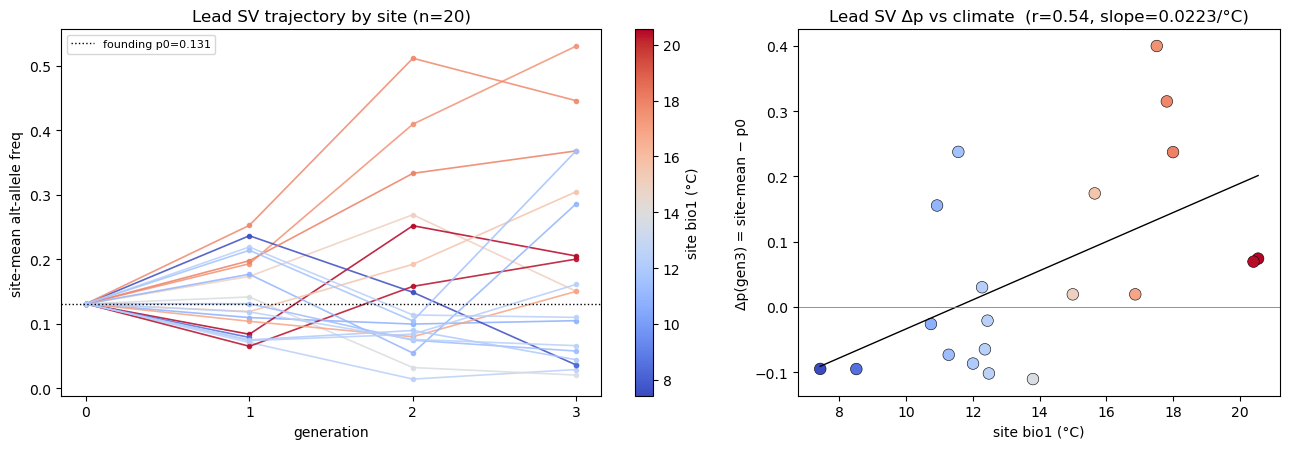

In [2]:
# Per-site allele-frequency trajectory of the LEAD SV: gen0(=shared p0) -> 1 -> 2 -> 3,
# one line per site, colored by site temperature (bio1). Up-in-warm = red lines rise.
gens=[0,1,2,3]; y=traj[:,:,lead]
norm=plt.Normalize(bio1.min(), bio1.max()); cmap=cm.coolwarm
fig, ax = plt.subplots(1,2, figsize=(13,4.6), gridspec_kw={"width_ratios":[1.4,1]})
for si in range(len(sites3)):
    ax[0].plot(gens, y[:,si], "-o", ms=3, lw=1.2, color=cmap(norm(bio1[si])), alpha=.85)
ax[0].axhline(p0[lead], color="k", ls=":", lw=1, label=f"founding p0={p0[lead]:.3f}")
ax[0].set_xlabel("generation"); ax[0].set_ylabel("site-mean alt-allele freq")
ax[0].set_xticks(gens); ax[0].set_title(f"Lead SV trajectory by site (n={len(sites3)})")
ax[0].legend(fontsize=8)
sm=cm.ScalarMappable(norm=norm,cmap=cmap); sm.set_array([])
fig.colorbar(sm, ax=ax[0], label="site bio1 (°C)")
# the headline GEA: site Δp(gen3) vs bio1
d=dp3[:,lead]; ok=np.isfinite(d)
ax[1].scatter(bio1[ok], d[ok], c=bio1[ok], cmap=cmap, s=70, edgecolor="k", lw=.4)
b,a=np.polyfit(bio1[ok], d[ok], 1); xs=np.array([bio1.min(),bio1.max()])
ax[1].plot(xs, a+b*xs, "k-", lw=1)
r=np.corrcoef(bio1[ok], d[ok])[0,1]
ax[1].axhline(0,color="grey",lw=.6); ax[1].set_xlabel("site bio1 (°C)")
ax[1].set_ylabel("Δp(gen3) = site-mean − p0"); ax[1].set_title(f"Lead SV Δp vs climate  (r={r:.2f}, slope={b:.4f}/°C)")
plt.tight_layout(); plt.show()

## Whole-block Δp across sites (coherence)

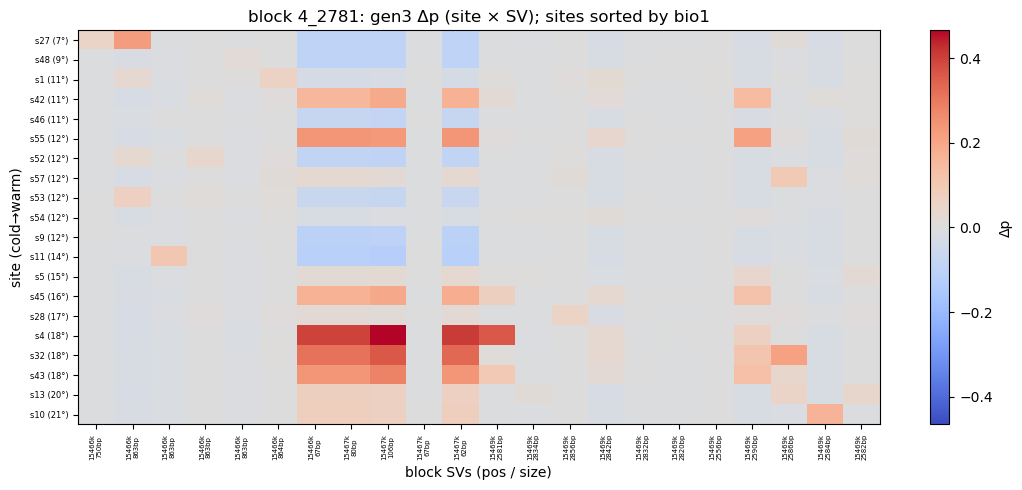

In [3]:
# Whole block: gen3 Δp per site (rows) x SV (cols), sites ordered by bio1. Coherent
# vertical bands = the block's SVs move together with climate.
oo=np.argsort(bio1)
fig, ax = plt.subplots(figsize=(11,5))
im=ax.imshow(dp3[oo], aspect="auto", cmap="coolwarm",
             vmin=-np.nanmax(np.abs(dp3)), vmax=np.nanmax(np.abs(dp3)))
ax.set_yticks(range(len(sites3))); ax.set_yticklabels([f"s{int(s)} ({bio1[i]:.0f}°)" for i,s in zip(oo,sites3[oo])], fontsize=6)
ax.set_xticks(range(len(bm))); ax.set_xticklabels([f"{int(p/1e3)}k\n{int(sz)}bp" for p,sz in zip(bm.pos,bm.sv_size)], fontsize=5, rotation=90)
ax.set_xlabel("block SVs (pos / size)"); ax.set_ylabel("site (cold→warm)")
ax.set_title(f"block {str(C['block'])}: gen3 Δp (site × SV); sites sorted by bio1")
fig.colorbar(im, label="Δp"); plt.tight_layout(); plt.show()

## Gene context

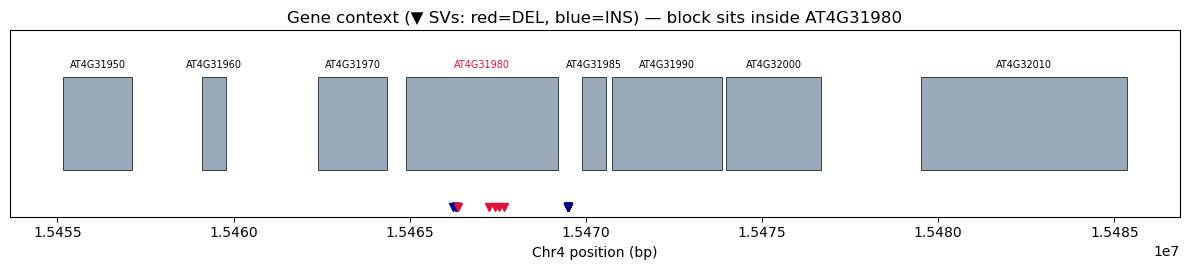

AT4G31980 spans 15,464,905–15,469,204; the 22-SV block (15,466,240–15,469,500) is intragenic.


In [4]:
# Gene context: AT4G31980 + neighbours, with the block's SVs drawn at their positions.
gs=C["gene_start"]; ge=C["gene_end"]; gid=C["gene_id"].astype(str)
fig, ax = plt.subplots(figsize=(12,2.8))
for s,e,g in zip(gs,ge,gid):
    ax.add_patch(plt.Rectangle((s,0.25),e-s,0.5, color="#9ab", ec="k", lw=.5))
    ax.text((s+e)/2, 0.8, g, fontsize=7, ha="center", rotation=0,
            color=("crimson" if g=="AT4G31980" else "k"))
for _,r in bm.iterrows():
    col="crimson" if r.alt_len<r.ref_len else "navy"
    ax.plot([r.pos],[0.05],"v",color=col,ms=6)
ax.set_ylim(0,1); ax.set_yticks([]); ax.set_xlabel(f"{str(C['chrom'])} position (bp)")
ax.set_title("Gene context (▼ SVs: red=DEL, blue=INS) — block sits inside AT4G31980")
plt.tight_layout(); plt.show()
print("AT4G31980 spans 15,464,905–15,469,204; the 22-SV block (15,466,240–15,469,500) is intragenic.")

## Reading this block

- The block sits **inside AT4G31980**; the lead signals are ~60–110 bp **deletions**
  (p0≈0.12) that **rise in warm gardens** across generations (B selection-coefficient
  z≈3.2, up-in-warm), plus a multi-allelic insertion site at the 3′ end.
- The trajectory + Δp-vs-bio1 panels are the honest readout at **N=20 sites** — judge the
  gradient by eye, not by a per-SV p-value.
- **SNP-independence:** compare the lead SV's best r² with assembly-panel vs short-read
  SNPs — if short-read r² is low, this is an SV a SNP-only GEA would (partly) miss.
- Caveats: still only ~20 sites of climate df; confirm with **cross-garden parallelism**
  and check AT4G31980's function before claiming adaptation.
